# testSCVIbatch.ipynb — cross-batch pair-MSE alignment loss

Inherits from `testRUVVAE_ZINB.ipynb` (uses the same TH subset + scVI-style
data prep). Calls [`model_scvi_batch_pair.SCVIWithBatchPairLoss`](model_scvi_batch_pair.py)
which adds an extra cross-batch MSE term to the standard scVI loss.

Pipeline:
1. Load data & prepare scVI format (counts in X, n_genes_on covariate)
2. `setup_anndata` + build `SCVIWithBatchPairLoss`
3. Forward validation: `pair_loss > 0` only when mini-batch has ≥ 2 batches
4. Train (100 epochs), watch `batch_pair_mse`
5. Evaluate alignment: iLISI / ASW vs baseline SCVI
6. Visualise: UMAP by batch, per-pair MSE convergence, latent `z` distribution

In [1]:
from scipy.sparse import csr_matrix, issparse
import numpy as np
import scanpy as sc
import pandas as pd


In [2]:
# ========== Load the same data subset as testRUVVAE_ZINB.ipynb ==========

adata = sc.read_h5ad(
    "/data3/junyi/six_datasets_4v3_500_1000gene_batchfinelr/AMY_batchscvi_full.h5ad"
)

# adata_subset = adata[
#     adata.obs["celltype.L2"].isin(
#         adata.obs["celltype.L2"].value_counts().head(2).index[1:2]
#     )
# ]
# adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]

print(f"adata_subset shape: {adata.shape}")
print(f"status counts:\n{adata.obs['status'].value_counts()}")
print(f"company counts:\n{adata.obs['company'].value_counts()}")

adata_subset shape: (247304, 16428)
status counts:
status
CUSUS    76001
CON      72106
CSRES    37968
CURES    36809
CSSUS    24420
Name: count, dtype: int64
company counts:
company
yunzhun     118081
beirui      114477
seekgene     14746
Name: count, dtype: int64


In [71]:
adata.layers

Layers with keys: 'batchpair_D1_counts', 'batchpair_D1_normlized', 'count_diff', 'counts', 'scvi_reconstructed_counts', None, 'scvi_norm', 'log1px', 'log1pscvi'

In [4]:
LAYER_NAME = "batchpair_D1_normlized"
COUNT_LAYER_NAME = "batchpair_D1_counts"

In [5]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz",
]

candidate_negative_control_genes = [
    "Oaz1", "Rps13", "Rps20", "Rpl27",
    "Aars", "Polr2f", "Psmd6", "Psmd7", "Psma5",
    "Ipo8", "Pop4", "Pes1", "Rer1",
    "Rpl13a", "Cyc1", "Sdha", "Ubc",
]

hkg_priority = candidate_negative_control_genes + hkg_priority


In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [7]:
adata.layers

Layers with keys: 'batchpair_D1_counts', 'batchpair_D1_normlized', 'count_diff', 'counts', 'scvi_reconstructed_counts', None

In [8]:
adata.layers[LAYER_NAME].sum(axis=1)

matrix([[10000.002],
        [10000.002],
        [10000.002],
        ...,
        [10000.002],
        [10000.002],
        [10000.002]], shape=(247304, 1), dtype=float32)

In [9]:
row_sums = adata.layers[LAYER_NAME].sum(axis=1)
if issparse(adata.layers[LAYER_NAME]):
    row_sums = np.asarray(row_sums).ravel()
else:
    row_sums = np.asarray(row_sums).ravel()

In [10]:
if np.allclose(row_sums, 1.0):
    adata.layers[LAYER_NAME] = adata.layers[LAYER_NAME] * 1e4
    print("每行 sum=1，已乘以 1e4")
else:
    print(f"未执行乘 1e4：行和并非全为 1（min={row_sums.min()}, max={row_sums.max()}）")


未执行乘 1e4：行和并非全为 1（min=9999.9990234375, max=10000.0048828125）


In [11]:
adata.layers[LAYER_NAME].min()

np.float32(1.1159961e-05)

In [12]:
adata.layers["scvi_norm"] =  adata.layers[LAYER_NAME].copy()


In [13]:
adata.layers

Layers with keys: 'batchpair_D1_counts', 'batchpair_D1_normlized', 'count_diff', 'counts', 'scvi_reconstructed_counts', None, 'scvi_norm'

In [14]:
mask = (adata.layers[COUNT_LAYER_NAME] != 0)

In [15]:
mask = ~(mask.toarray())

In [16]:
adata.layers["scvi_norm"][mask] = 0

In [17]:
adata.layers["scvi_norm"].min()

np.float32(0.0)

In [18]:

def to_sparse_int(arr, dtype=np.float32):
    """把 numpy / float / 稀疏数组转换成 (n_cells, n_genes) 的 csr int 矩阵。

    - 输入若为稀疏矩阵：保持格式，只把 dtype 转成 int32。
    - 输入若为稠密 ndarray：rint 截断后构造 csr（counts 必须是离散整数）。
    - 用于把 decoder 抽样得到的 counts 写入 adata.layers["..."]，避免 h5ad
      把 float 数组按 ~8 字节/元素存储（counts 通常很稀疏 + 数值小）。
    """
    if issparse(arr):
        return csr_matrix(arr).astype(dtype)
    arr = np.asarray(arr)
    if arr.ndim == 1:
        # 防御性：误传 1D 时强制 reshape 成单行矩阵
        arr = arr.reshape(1, -1)
    if dtype == np.int32: 
        return csr_matrix(np.rint(arr).astype(dtype))
    else:
        return csr_matrix(arr.astype(dtype))


In [19]:
# do only if the layer is not already sparse int
if not issparse(adata.layers["scvi_norm"]) or adata.layers["scvi_norm"].dtype != np.float32:
    layer_val = to_sparse_int(adata.layers["scvi_norm"], dtype=np.float32)
    layer_val.eliminate_zeros()
    adata.layers["scvi_norm"] = layer_val

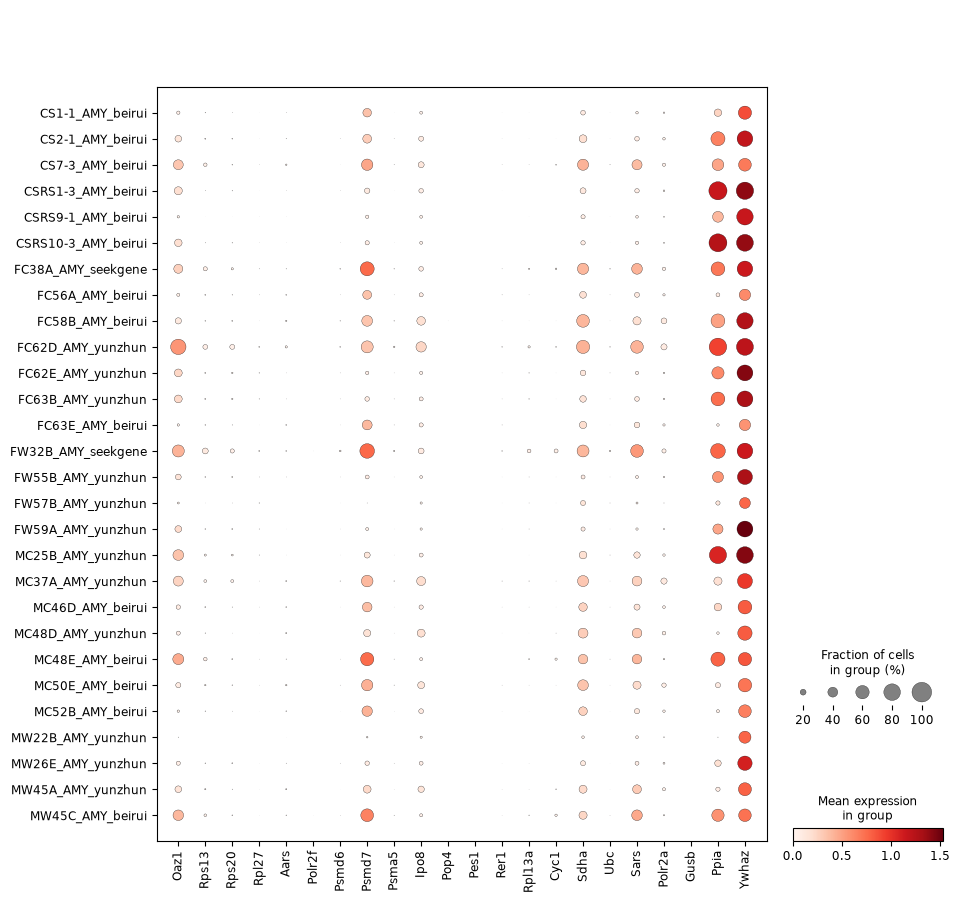

In [20]:
seen = set()
hkg_genes = []
for g in hkg_priority:
    if g in adata.var_names and g not in seen:
        seen.add(g)
        hkg_genes.append(g)

fig = sc.pl.dotplot(
    adata,
    var_names=hkg_genes,
    groupby="sample",
    layer="scvi_norm",
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
)
fig.show()


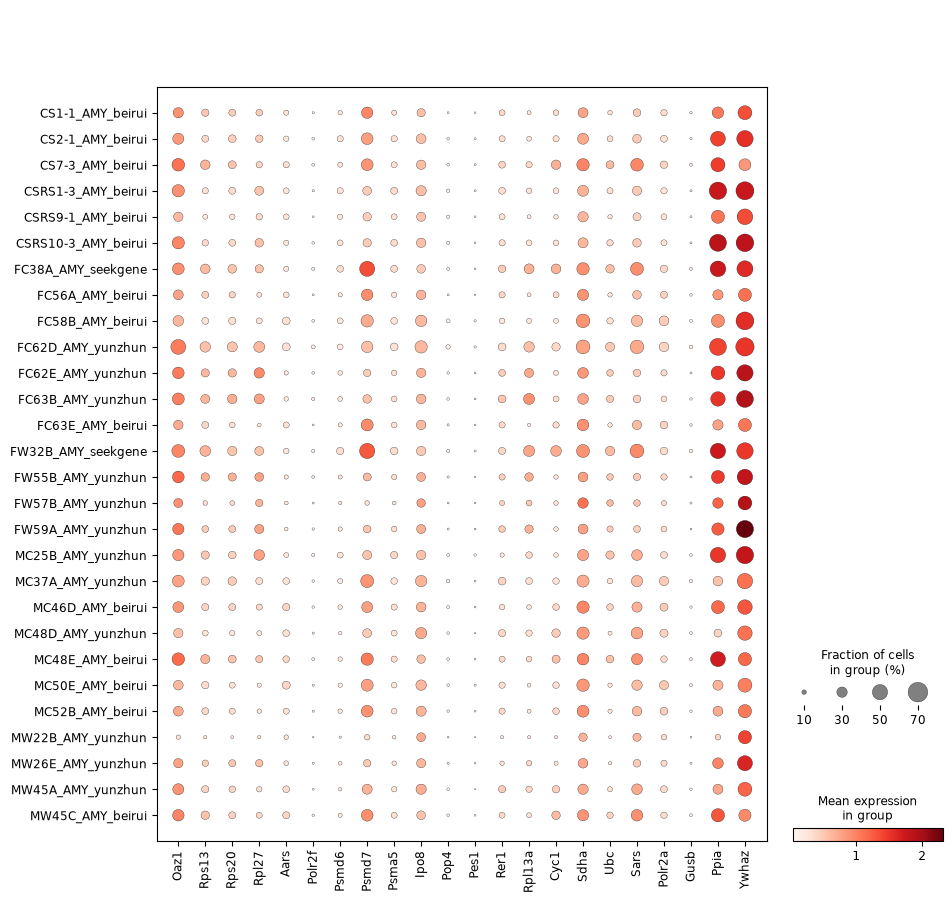

In [21]:

fig = sc.pl.dotplot(
    adata,
    var_names=hkg_genes,
    groupby="sample",
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
)
fig.show()


In [22]:
# print the max,min,mean value of the normalized in batchpair_D1_normlized 
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.X.max()}")
print(f"Min value in adata.X: {adata.X.min()}")
print(f"Mean value in adata.X: {adata.X.mean()}")


Max value in adata.X: 5421.5185546875
Min value in adata.X: 0.0
Mean value in adata.X: 0.6087167859077454


In [23]:
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.layers['scvi_norm'].max()}")
print(f"Min value in adata.X: {adata.layers['scvi_norm'].min()}")
print(f"Mean value in adata.X: {adata.layers['scvi_norm'].mean()}")


Max value in adata.X: 2581.03564453125
Min value in adata.X: 0.0
Mean value in adata.X: 0.4098057150840759


In [24]:
sc.pp.log1p(adata)

In [25]:
sc.tl.rank_genes_groups(adata, groupby="company", method="wilcoxon",pct=True)

In [26]:
df_all = pd.DataFrame()
for company in adata.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata, group=company)
    df_company["company"] = company
    df_all = pd.concat([df_all, df_company], ignore_index=True)

Ranking genes for company: seekgene
Ranking genes for company: yunzhun
Ranking genes for company: beirui


In [27]:
df_all_filtered = df_all[df_all["pvals_adj"] < 0.05]

In [28]:
df_all_filtered.value_counts("company")

company
yunzhun     10123
seekgene     9755
beirui       9567
Name: count, dtype: int64

In [29]:
adata.layers["log1px"] = adata.X.copy()

In [30]:
adata.X = adata.layers[LAYER_NAME].copy()

In [31]:
sc.pp.log1p(adata)

In [32]:
adata.layers["log1pscvi"] = adata.X.copy()

In [ ]:
adata_con = adata[adata.obs["Model"] == "CON_M"]

In [54]:
adata_con.X = adata_con.layers["log1pscvi"].copy()
sc.tl.rank_genes_groups(adata_con, groupby="company", method="wilcoxon",pct=True)

In [55]:
df_con_correct = pd.DataFrame()
for company in adata_con.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata_con, group=company)
    df_company["company"] = company
    df_con_correct = pd.concat([df_con_correct, df_company], ignore_index=True)

Ranking genes for company: beirui
Ranking genes for company: yunzhun


In [56]:
df_con_correct_filtered = df_con_correct[df_con_correct["pvals_adj"] < 0.05]
df_con_correct_filtered.value_counts("company")

company
beirui     15902
yunzhun    15902
Name: count, dtype: int64

In [57]:
adata_con.X = adata_con.layers["log1px"].copy()
sc.tl.rank_genes_groups(adata_con, groupby="company", method="wilcoxon",pct=True)


In [58]:
df_raw = pd.DataFrame()
for company in adata_con.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata_con, group=company)
    df_company["company"] = company
    df_raw = pd.concat([df_raw, df_company], ignore_index=True)
df_raw_filtered = df_raw[df_raw["pvals_adj"] < 0.05]
print(f"Number of significant genes for each company:\n{df_raw_filtered.value_counts('company')}")

Ranking genes for company: beirui
Ranking genes for company: yunzhun
Number of significant genes for each company:
company
beirui     8095
yunzhun    8095
Name: count, dtype: int64


In [59]:
df_raw_filtered['absFC'] = df_raw_filtered['logfoldchanges'].abs()
df_con_correct_filtered['absFC'] = df_con_correct_filtered['logfoldchanges'].abs()

In [63]:
df_raw_filtered.groupby('company').agg({'absFC': ['mean', 'std']})

absFC         
             mean      std
company                   
beirui   0.686857  0.52114
yunzhun  0.686857  0.52114

In [64]:
df_con_correct_filtered.groupby('company').agg({'absFC': ['mean', 'std']})

absFC          
             mean       std
company                    
beirui   0.335615  0.320661
yunzhun  0.335615  0.320661

In [ ]:
# df_status_raw = pd.DataFrame()
# adata.X = adata.layers["log1px"].copy()
# for status in adata.obs.status.unique():
#     adata_disease = adata[(adata.obs.status == status) | (adata.obs.status == "CON") ]
#     sc.tl.rank_genes_groups(adata_disease, groupby="status", method="wilcoxon",pct=True)
#     df_status_tmp = sc.get.rank_genes_groups_df(adata_disease, group=status)
#     df_status_tmp["status"] = status
#     df_status_raw = pd.concat([df_status_raw, df_status_tmp], ignore_index=True)
# df_status_raw_filtered = df_status_raw[df_status_raw["pvals_adj"] < 0.05]
# df_status_raw_filtered['Direction'] = df_status_raw_filtered['logfoldchanges'].apply(lambda x: 'up' if x > 0 else 'down')

In [ ]:
# df_status_corrected = pd.DataFrame()
# adata.X = adata.layers["log1pscvi"].copy()
# for status in adata.obs.status.unique():
#     adata_disease = adata[(adata.obs.status == status) | (adata.obs.status == "CON")]
#     sc.tl.rank_genes_groups(adata_disease, groupby="status", method="wilcoxon", pct=True)
#     df_status_tmp = sc.get.rank_genes_groups_df(adata_disease, group=status)
#     df_status_tmp["status"] = status
#     df_status_corrected = pd.concat([df_status_corrected, df_status_tmp], ignore_index=True)
# df_status_corrected_filtered = df_status_corrected[df_status_corrected["pvals_adj"] < 0.05]

In [66]:
mouse_brain_hkg = [
    # === 结构/骨架（必须有）===
    "Actb",          # β-actin
    "Tuba1a",        # α-tubulin
    "Ubc",           # ubiquitin
    "Uba52",         # ubiquitin-60S ribosomal
    # === 蛋白酶体/折叠（稳定）===
    "Psmd6", "Psmd7", "Psma5",
    "Hsp90aa1", "Hsp90ab1",  # Hsp90 伴侣
    "Ywhaz",              # 14-3-3ζ
    # === 线粒体（log-normalize 数据里必须加）===
    "Sdha", "Cyc1",
    "Cox4i1", "Cox5b",
    "Ndufa4", "Ndufb8",
    "Atp5f1b",
    # === 翻译机器（精选）===
    "Eef1a1",
    "Rplp0", "Rpl19", "Rps18",   # 比 Rps13/Rps20 稳
    "Polr2a",
    # === 转录机器 ===
    "Tbp",
    # === 代谢稳定 ===
    "Ppia", "Pgk1",
]

In [67]:
adata_con.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,umap_seurat_2,Neurotransmitter,doublet_cluster,celltype,Model,_pair_group,n_genes_on,_pair_batch,_scvi_batch,_scvi_labels
AACACACCATATGGCT-1AMY_beirui_MW45C,MW45C_AMY_beirui,2524,7.833996,6588.0,8.793157,38.752277,44.899818,52.079539,64.238009,1.0,...,-0.482353,Glut,0,AMY Cav1_Frmpd1 Glut,CON_M,AMY Cav1_Frmpd1 Glut__CON,0.053433,beirui,0,0
AACGAAACATGACAGG-1AMY_beirui_MW45C,MW45C_AMY_beirui,1295,7.167038,2239.0,7.714231,28.494864,35.908888,45.645377,64.493077,2.0,...,0.003545,Glut,0,AMY Cav1_Frmpd1 Glut,CON_M,AMY Cav1_Frmpd1 Glut__CON,-1.239355,beirui,0,0
AACGAAAGTATGTCAC-1AMY_beirui_MW45C,MW45C_AMY_beirui,2604,7.865188,5456.0,8.604654,30.553519,36.326979,43.988270,57.074780,1.0,...,-0.341919,Glut,0,AMY Cav1_Frmpd1 Glut,CON_M,AMY Cav1_Frmpd1 Glut__CON,0.140755,beirui,0,0
AATGGAATCTCGAGTA-1AMY_beirui_MW45C,MW45C_AMY_beirui,2444,7.801800,4920.0,8.501267,27.398374,33.414634,41.077236,55.650407,0.0,...,-0.314045,Glut,0,AMY Cav1_Frmpd1 Glut,CON_M,AMY Cav1_Frmpd1 Glut__CON,-0.029629,beirui,0,0
AATTCCTCAGTTCACA-1AMY_beirui_MW45C,MW45C_AMY_beirui,2742,7.916807,6854.0,8.832733,35.380800,41.581558,48.876568,61.817917,2.0,...,-0.590043,Glut,0,AMY Cav1_Frmpd1 Glut,CON_M,AMY Cav1_Frmpd1 Glut__CON,0.287711,beirui,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCCACCACACTGAATC-1AMY_yunzhun_MW26E,MW26E_AMY_yunzhun,1695,7.436028,2937.0,7.985485,28.328226,33.946204,42.185904,59.312223,4.0,...,2.886273,NN,0,VLMC,CON_M,VLMC__CON,-0.844277,yunzhun,0,214
TCGCTTGTCAGAGTTC-1AMY_yunzhun_MW26E,MW26E_AMY_yunzhun,1164,7.060476,1831.0,7.513164,31.075915,37.028946,47.351174,63.735664,7.0,...,2.928087,NN,0,VLMC,CON_M,VLMC__CON,-1.407609,yunzhun,0,214
TTCCTCTGTTGCATAC-1AMY_yunzhun_MW26E,MW26E_AMY_yunzhun,1129,7.029973,1711.0,7.445417,27.936879,34.365868,45.704267,63.237873,12.0,...,2.905126,NN,0,VLMC,CON_M,VLMC__CON,-1.441686,yunzhun,0,214
TTGTTGTTCAGTGATC-1AMY_yunzhun_MW26E,MW26E_AMY_yunzhun,1173,7.068172,1973.0,7.587817,30.765332,37.303599,47.440446,65.889508,7.0,...,2.376767,NN,0,VLMC,CON_M,VLMC__CON,-1.387376,yunzhun,0,214


In [68]:
# 自包含：本 cell 重新准备 CON 内的 raw / corrected 表达矩阵
from sklearn.metrics import roc_auc_score
from scipy.sparse import issparse

con_company = adata_con.obs["company"].values
companies = sorted(set(con_company))

X_raw_con = adata_con.layers["log1px"]
X_corr_con = adata_con.layers["log1pscvi"]
if issparse(X_raw_con):
    X_raw_con = X_raw_con.toarray()
if issparse(X_corr_con):
    X_corr_con = X_corr_con.toarray()
X_raw_con = np.asarray(X_raw_con)
X_corr_con = np.asarray(X_corr_con)


def per_company_aucs(x_col, y_label, comps):
    """对单基因，返回每个 company one-vs-rest 的 abs(AUC-0.5)+0.5（dict）。"""
    out = {}
    for comp in comps:
        y = (y_label == comp).astype(int)
        if y.sum() == 0 or y.sum() == len(y):
            out[comp] = np.nan
            continue
        try:
            a = roc_auc_score(y, x_col)
        except ValueError:
            out[comp] = np.nan
            continue
        out[comp] = abs(a - 0.5) + 0.5
    return out


hkg_in_data = [g for g in mouse_brain_hkg if g in adata_con.var_names]
print(f"hkg_priority 共 {len(mouse_brain_hkg)} 个，adata_con 中存在 {len(hkg_in_data)} 个")
print(f"companies: {companies}")
print(f"company 分布: {dict(zip(*np.unique(con_company, return_counts=True)))}\n")

# 每个基因 × 每个 company 都算 AUC，存成 long-form DataFrame
rows = []
for g in hkg_in_data:
    col = list(adata_con.var_names).index(g)
    raw_a = per_company_aucs(X_raw_con[:, col],  con_company, companies)
    cor_a = per_company_aucs(X_corr_con[:, col], con_company, companies)
    for comp in companies:
        rows.append({
            "gene": g,
            "company": comp,
            "raw_AUC":  raw_a.get(comp, np.nan),
            "corr_AUC": cor_a.get(comp, np.nan),
            "delta":    cor_a.get(comp, np.nan) - raw_a.get(comp, np.nan),
        })

hkg_auc_df = pd.DataFrame(rows)

# 再算每基因的 best（三个公司 AUC 的最大值）作为汇总列
best_per_gene = (
    hkg_auc_df.groupby("gene")[["raw_AUC", "corr_AUC"]]
    .max()
    .rename(columns={"raw_AUC": "best_raw", "corr_AUC": "best_corr"})
    .reset_index()
)
best_per_gene["delta_best"] = best_per_gene["best_corr"] - best_per_gene["best_raw"]
hkg_auc_df = hkg_auc_df.merge(best_per_gene, on="gene", how="left")

print("=== 每个 HK 基因 × 每个 company 的 raw / corr AUC ===")
print(hkg_auc_df.to_string(index=False))

# 汇总：每个公司的 raw / corr AUC 均值
print("\n=== 按 company 汇总（mean ± std）===")
summary_by_comp = (
    hkg_auc_df.groupby("company")
    .agg(
        n=("gene", "count"),
        raw_mean=("raw_AUC", "mean"),
        raw_std=("raw_AUC", "std"),
        corr_mean=("corr_AUC", "mean"),
        corr_std=("corr_AUC", "std"),
        delta_mean=("delta", "mean"),
        frac_raw_gt_0_6=("raw_AUC", lambda s: (s > 0.6).mean()),
        frac_corr_gt_0_6=("corr_AUC", lambda s: (s > 0.6).mean()),
    )
    .round(4)
    .reset_index()
)
print(summary_by_comp.to_string(index=False))

print("\n=== best across companies（每基因三公司最大 AUC）===")
print(best_per_gene.to_string(index=False))

# best 的整体 mean
print(
    f"\n整体 best: raw mean={best_per_gene['best_raw'].mean():.3f}  "
    f"corr mean={best_per_gene['best_corr'].mean():.3f}  "
    f"Δ={best_per_gene['delta_best'].mean():+.3f}"
)
hkg_auc_df

hkg_priority 共 25 个，adata_con 中存在 24 个
companies: ['beirui', 'yunzhun']
company 分布: {'beirui': np.int64(7513), 'yunzhun': np.int64(34303)}

=== 每个 HK 基因 × 每个 company 的 raw / corr AUC ===
    gene company  raw_AUC  corr_AUC    delta  best_raw  best_corr  delta_best
    Actb  beirui 0.596439  0.844664 0.248225  0.596439   0.844664    0.248225
    Actb yunzhun 0.596439  0.844664 0.248225  0.596439   0.844664    0.248225
  Tuba1a  beirui 0.655289  0.888836 0.233547  0.655289   0.888836    0.233547
  Tuba1a yunzhun 0.655289  0.888836 0.233547  0.655289   0.888836    0.233547
     Ubc  beirui 0.537009  0.777282 0.240273  0.537009   0.777282    0.240273
     Ubc yunzhun 0.537009  0.777282 0.240273  0.537009   0.777282    0.240273
   Uba52  beirui 0.512876  0.733336 0.220460  0.512876   0.733336    0.220460
   Uba52 yunzhun 0.512876  0.733336 0.220460  0.512876   0.733336    0.220460
   Psmd6  beirui 0.511359  0.865756 0.354397  0.511359   0.865756    0.354397
   Psmd6 yunzhun 0.511359  0.8657

,gene,company,raw_AUC,corr_AUC,delta,best_raw,best_corr,delta_best
0,Actb,beirui,0.596439,0.844664,0.248225,0.596439,0.844664,0.248225
1,Actb,yunzhun,0.596439,0.844664,0.248225,0.596439,0.844664,0.248225
2,Tuba1a,beirui,0.655289,0.888836,0.233547,0.655289,0.888836,0.233547
3,Tuba1a,yunzhun,0.655289,0.888836,0.233547,0.655289,0.888836,0.233547
4,Ubc,beirui,0.537009,0.777282,0.240273,0.537009,0.777282,0.240273
5,Ubc,yunzhun,0.537009,0.777282,0.240273,0.537009,0.777282,0.240273
6,Uba52,beirui,0.512876,0.733336,0.220460,0.512876,0.733336,0.220460
7,Uba52,yunzhun,0.512876,0.733336,0.220460,0.512876,0.733336,0.220460
8,Psmd6,beirui,0.511359,0.865756,0.354397,0.511359,0.865756,0.354397
9,Psmd6,yunzhun,0.511359,0.865756,0.354397,0.511359,0.865756,0.354397


In [69]:
# ============================================================================
# 每个 company raw DEG 的 top-10，做该 company vs other companies 的 AUC
# 每一行 = 一个 company 的一个 top DEG，不再区分 source_company / test_company
# ============================================================================
TOP_N = 10


def top_n_genes_per_company_from_df(df, group_col, gene_col, lfc_col, n=TOP_N):
    """从已过滤的 DEG DataFrame 取每个 company 的 top-N 基因。"""
    out = {}
    for company, sub in df.groupby(group_col):
        ranked = sub.assign(_abs_logfc=sub[lfc_col].abs())
        ranked = ranked.sort_values("_abs_logfc", ascending=False)
        out[company] = ranked.head(n).copy()
    return out


# df_raw_filtered 已按 pvals_adj < 0.05 过滤
_top10_per_company = top_n_genes_per_company_from_df(
    df_raw_filtered,
    group_col="company",
    gene_col="names",
    lfc_col="logfoldchanges",
    n=TOP_N,
)

_var_index = {gene: i for i, gene in enumerate(adata_con.var_names)}
_top10_rows = []
for company, company_df in _top10_per_company.items():
    for _, gene_row in company_df.iterrows():
        gene = str(gene_row["names"])
        if gene not in _var_index:
            continue
        col = _var_index[gene]

        # 只计算该 company vs all other companies 的 one-vs-rest AUC
        y_company = (con_company == company).astype(int)
        raw_auc = abs(roc_auc_score(y_company, X_raw_con[:, col]) - 0.5) + 0.5
        corr_auc = abs(roc_auc_score(y_company, X_corr_con[:, col]) - 0.5) + 0.5

        _top10_rows.append({
            "company": company,
            "gene": gene,
            "raw_logFC": float(gene_row["logfoldchanges"]),
            "raw_AUC": raw_auc,
            "corr_AUC": corr_auc,
            "delta": corr_auc - raw_auc,
        })

top10_auc_df = pd.DataFrame(_top10_rows).sort_values(
    ["company", "raw_logFC"],
    key=lambda s: s.abs() if s.name == "raw_logFC" else s,
    ascending=[True, False],
).reset_index(drop=True)

summary_top10_by_company = (
    top10_auc_df.groupby("company")
    .agg(
        n=("gene", "count"),
        raw_mean=("raw_AUC", "mean"),
        raw_std=("raw_AUC", "std"),
        corr_mean=("corr_AUC", "mean"),
        corr_std=("corr_AUC", "std"),
        delta_mean=("delta", "mean"),
        frac_raw_gt_0_6=("raw_AUC", lambda s: (s > 0.6).mean()),
        frac_corr_gt_0_6=("corr_AUC", lambda s: (s > 0.6).mean()),
    )
    .round(4)
    .reset_index()
)

print(f"top10_auc_df shape: {top10_auc_df.shape}")
print(f"summary_top10_by_company shape: {summary_top10_by_company.shape}")

top10_auc_df

top10_auc_df shape: (20, 6)
summary_top10_by_company shape: (2, 9)


,company,gene,raw_logFC,raw_AUC,corr_AUC,delta
0,beirui,Gm43140,-4.460603,0.526135,0.953922,0.427787
1,beirui,Gm10097,-4.082307,0.518937,0.971184,0.452247
2,beirui,Gm36992,-3.618404,0.536297,0.932641,0.396344
3,beirui,mt-Nd3,-3.605795,0.639852,0.825090,0.185238
4,beirui,Gm29587,-3.579403,0.557588,0.932369,0.374781
5,beirui,Gm48239,-3.568236,0.555970,0.896215,0.340245
6,beirui,Uchl4,-3.530196,0.527753,0.966909,0.439156
7,beirui,C630031E19Rik,-3.493738,0.528450,0.896189,0.367739
8,beirui,Gm29994,-3.468346,0.513779,0.936573,0.422794
9,beirui,Gm15632,-3.391301,0.514062,0.941728,0.427666
